In [11]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score

from sklearn.metrics import classification_report

In [2]:
df = pd.read_excel("/content/Customer_feedback.xlsx")

print(df.head())

                                          Feedback           Category
0            Wrong color received and I need help.            Product
1        Gift wrapping available for order #82633.    General Inquiry
2   Checkout page not loading for my recent order.  Technical Support
3        Package not received on my first attempt.           Delivery
4  Password reset not working as soon as possible.  Technical Support


In [3]:
print(df.shape)

print(df.info())

print(df["Category"].value_counts())

(1056, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Feedback  1056 non-null   object
 1   Category  1056 non-null   object
dtypes: object(2)
memory usage: 16.6+ KB
None
Category
Billing              212
General Inquiry      211
Delivery             211
Technical Support    211
Product              201
product               10
Name: count, dtype: int64


In [4]:
X = df["Feedback"]

y = df["Category"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [6]:
model = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", MultinomialNB())
])

In [7]:
model.fit(X_train, y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()),
                ('classifier', MultinomialNB())])

In [8]:
y_pred = model.predict(X_test)

In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9716981132075472


In [12]:
print(classification_report(y_test, y_pred))

                   precision    recall  f1-score   support

          Billing       1.00      0.96      0.98        28
         Delivery       0.96      1.00      0.98        49
  General Inquiry       1.00      0.97      0.99        39
          Product       0.95      0.95      0.95        39
Technical Support       0.96      1.00      0.98        55
          product       0.00      0.00      0.00         2

         accuracy                           0.97       212
        macro avg       0.81      0.81      0.81       212
     weighted avg       0.96      0.97      0.97       212



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
feedback = ["My package has not arrived yet."]

prediction = model.predict(feedback)

print(prediction[0])

Delivery


In [14]:
feedback = input("Enter customer feedback: ")

prediction = model.predict([feedback])[0]

department = {
    "Billing": "Finance Team",
    "Delivery": "Logistics Team",
    "Product": "Quality Assurance Team",
    "Technical Support": "IT Support Team",
    "General Inquiry": "Customer Care Team"
}

print("\nPredicted Category :", prediction)
print("Route To :", department[prediction])

Enter customer feedback: Can I cancel my recent order?

Predicted Category : General Inquiry
Route To : Customer Care Team


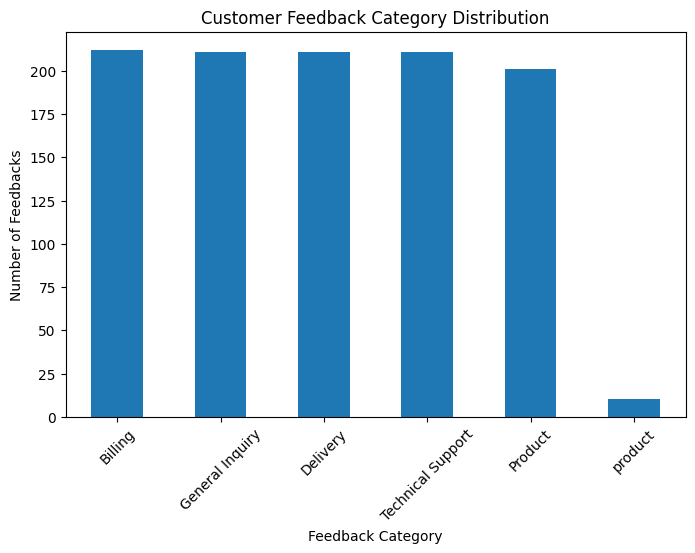

In [16]:
import matplotlib.pyplot as plt

category_counts = df["Category"].value_counts()

plt.figure(figsize=(8,5))
category_counts.plot(kind="bar")

plt.xlabel("Feedback Category")
plt.ylabel("Number of Feedbacks")
plt.title("Customer Feedback Category Distribution")

plt.xticks(rotation=45)
plt.show()